<a href="https://colab.research.google.com/github/estebanszd/Clase-Introducci-n-/blob/main/Actividad_an%C3%A1lisis_exploratorio_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
recetas = pd.read_csv("https://raw.githubusercontent.com/Gustavo-Bruges/ciencia-de-datos-unab/refs/heads/datos/recipes_cocina.csv")


In [6]:
departamentos = ["Santander", "Alántico", "Norte de Santander"]
capitales = ["Bucaramanga", "Barraquilla", "Cúcuta"]

In [7]:
print(type(departamentos))

<class 'list'>


In [8]:
colombia = dict(zip(departamentos, capitales))

In [9]:
colombia

{'Santander': 'Bucaramanga',
 'Alántico': 'Barraquilla',
 'Norte de Santander': 'Cúcuta'}

In [10]:
colombia["Valle del Cauca"] = "Cali"

In [11]:
for dep, cap in colombia.items():
  print(dep, cap)

Santander Bucaramanga
Alántico Barraquilla
Norte de Santander Cúcuta
Valle del Cauca Cali


In [12]:
municipios = ["Floridablanca", "Girón", "Piedecuesta"]

In [13]:
entidades = {"Santander": municipios}

In [14]:
entidades

{'Santander': ['Floridablanca', 'Girón', 'Piedecuesta']}

In [15]:
entidades ["Santander"][0:3:2]

['Floridablanca', 'Piedecuesta']

In [16]:
recetas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14426 entries, 0 to 14425
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      14426 non-null  int64  
 1   name            14426 non-null  object 
 2   url             14426 non-null  object 
 3   author          14426 non-null  object 
 4   date_published  14426 non-null  object 
 5   ingredients     14417 non-null  object 
 6   calories        14226 non-null  float64
 7   fat             14070 non-null  float64
 8   carbs           14212 non-null  float64
 9   protein         14178 non-null  float64
 10  avg_rating      13454 non-null  float64
 11  total_ratings   13454 non-null  float64
 12  reviews         13353 non-null  float64
 13  prep_time       14426 non-null  int64  
 14  cook_time       14426 non-null  int64  
 15  total_time      14426 non-null  int64  
 16  servings        14405 non-null  float64
dtypes: float64(8), int64(4), object

In [17]:
recetas["author"].value_counts(normalize=True).round(2)*100

,proportion
author,
John Mitzewich,5.0
Nicole McLaughlin,2.0
TheDailyGourmet,1.0
Kim,1.0
Allrecipes Member,1.0
...,...
htiz,0.0
Kathy Van Pelt,0.0
DEED330,0.0


In [18]:
recetas["author"].nbytes


115408

# CONVERTIR MI VARIABLE A VARIABLE CATEGÓRICA

In [19]:
recetas["author"] = recetas["author"].astype("category")

In [20]:
recetas.info

<bound method DataFrame.info of        Unnamed: 0                                               name  \
0               1           Chewy Whole Wheat Peanut Butter Brownies   
1               2                                 Pumpkin Pie Eggnog   
2               3                       Eggs Poached in Tomato Sauce   
3               4                               Minestrone Casserole   
4               5                              Yummy Stuffed Peppers   
...           ...                                                ...   
14421       14422                                 Cheesy Kale Quiche   
14422       14423             Fabulous Chicken Cordon Bleu Casserole   
14423       14424  Absolutely Wonderful Cheesy, Creamy Spinach Ar...   
14424       14425                              Gluten-Free Fruitcake   
14425       14426                        Chef John's Irish Pork Stew   

                                                     url           author  \
0      https://www.allrecipes.com/recipe/140717/chewy...           DMOMMY   
1      https://www.allrecipes.com/recipe/269204/pumpk...     Bobbie Susan   
2      https://www.allrecipes.com/recipe/238054/eggs-...             Bren   
3      https://www.allrecipes.com/minestrone-casserol...     Sarah Brekke   
4      https://www.allrecipes.com/recipe/241937/yummy...    Procrastigirl   
...                                                  ...              ...   
14421  https://www.allrecipes.com/recipe/244249/chees...       ally-gator   
14422  https://www.allrecipes.com/fabulous-chicken-co...   Lindsay Breeze   
14423  https://www.allrecipes.com/recipe/262412/absol...   Shamrock Farms   
14424  https://www.allrecipes.com/recipe/268501/glute...  Buckwheat Queen   
14425  https://www.allrecipes.com/recipe/236988/chef-...   John Mitzewich   

      date_published                                        ingredients  \
0         2020-06-18  ⅓ cup margarine, softened, ⅔ cup white sugar, ...   
1         2022-09-26  12  egg yolks, 2 cups heavy whipping cream, ½ ...   
2         2018-06-08  2 tablespoons olive oil, or to taste, ½  onion...   
3         2025-03-03  4 cups dried mafalda pasta (mini lasagna noodl...   
4         2024-12-11  4 green bell peppers, halved lengthwise and se...   
...              ...                                                ...   
14421     2022-01-14  1 (9 inch) pie crust pastry, ½ (8 ounce) packa...   
14422     2024-01-08  8 ounces egg noodles, 1/2 cup butter, 1/2 cup ...   
14423     2022-01-14  ½ cup Shamrock Farms® Premium Sour Cream, ½ cu...   
14424     2023-01-22  ¼ cup raisins, ¼ cup golden raisins, ¼ cup dri...   
14425     2024-11-16  1 (2 ½ pound) boneless pork shoulder, cut into...   

       calories   fat  carbs  protein  avg_rating  total_ratings  reviews  \
0         222.0  13.0   24.0      6.0         4.4           47.0     36.0   
1         477.0  31.0   43.0      8.0         5.0            1.0      1.0   
2         354.0  18.0   32.0     20.0         4.8            4.0      4.0   
3         356.0   9.0   53.0     19.0         4.3           14.0     13.0   
4         366.0  22.0   23.0     19.0         4.7           84.0     67.0   
...         ...   ...    ...      ...         ...            ...      ...   
14421     338.0  25.0   15.0     14.0         4.8           20.0     17.0   
14422     572.0  37.0   28.0     30.0         4.9           14.0     14.0   
14423     244.0  13.0   22.0     11.0         NaN            NaN      NaN   
14424     401.0  20.0   45.0      5.0         5.0            6.0      6.0   
14425     401.0  19.0   33.0     20.0         4.8          333.0    274.0   

       prep_time  cook_time  total_time  servings  
0             20         35          55      16.0  
1             10          5         495       8.0  
2             10         75          85       4.0  
3             20         40          60       8.0  
4             30         95         125       8.0  
...          ...        ...         ... 

In [21]:
recetas["author"].nbytes

95228

In [22]:
recetas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14426 entries, 0 to 14425
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Unnamed: 0      14426 non-null  int64   
 1   name            14426 non-null  object  
 2   url             14426 non-null  object  
 3   author          14426 non-null  category
 4   date_published  14426 non-null  object  
 5   ingredients     14417 non-null  object  
 6   calories        14226 non-null  float64 
 7   fat             14070 non-null  float64 
 8   carbs           14212 non-null  float64 
 9   protein         14178 non-null  float64 
 10  avg_rating      13454 non-null  float64 
 11  total_ratings   13454 non-null  float64 
 12  reviews         13353 non-null  float64 
 13  prep_time       14426 non-null  int64   
 14  cook_time       14426 non-null  int64   
 15  total_time      14426 non-null  int64   
 16  servings        14405 non-null  float64 
dtypes: category(

In [23]:
recetas['cat_calories'] = recetas['calories']>500

In [24]:
recetas['cat_calories'].nbytes

14426

In [25]:
recetas.head()

,Unnamed: 0,name,url,author,date_published,ingredients,calories,fat,carbs,protein,avg_rating,total_ratings,reviews,prep_time,cook_time,total_time,servings,cat_calories
0,1,Chewy Whole Wheat Peanut Butter Brownies,https://www.allrecipes.com/recipe/140717/chewy...,DMOMMY,2020-06-18,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",222.0,13.0,24.0,6.0,4.4,47.0,36.0,20,35,55,16.0,False
1,2,Pumpkin Pie Eggnog,https://www.allrecipes.com/recipe/269204/pumpk...,Bobbie Susan,2022-09-26,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",477.0,31.0,43.0,8.0,5.0,1.0,1.0,10,5,495,8.0,False
2,3,Eggs Poached in Tomato Sauce,https://www.allrecipes.com/recipe/238054/eggs-...,Bren,2018-06-08,"2 tablespoons olive oil, or to taste, ½ onion...",354.0,18.0,32.0,20.0,4.8,4.0,4.0,10,75,85,4.0,False
3,4,Minestrone Casserole,https://www.allrecipes.com/minestrone-casserol...,Sarah Brekke,2025-03-03,4 cups dried mafalda pasta (mini lasagna noodl...,356.0,9.0,53.0,19.0,4.3,14.0,13.0,20,40,60,8.0,False
4,5,Yummy Stuffed Peppers,https://www.allrecipes.com/recipe/241937/yummy...,Procrastigirl,2024-12-11,"4 green bell peppers, halved lengthwise and se...",366.0,22.0,23.0,19.0,4.7,84.0,67.0,30,95,125,8.0,False


In [26]:
recetas['cat_calories'] = recetas['calories'].astype('category')

In [27]:
recetas['cat_calories'].nbytes

37748

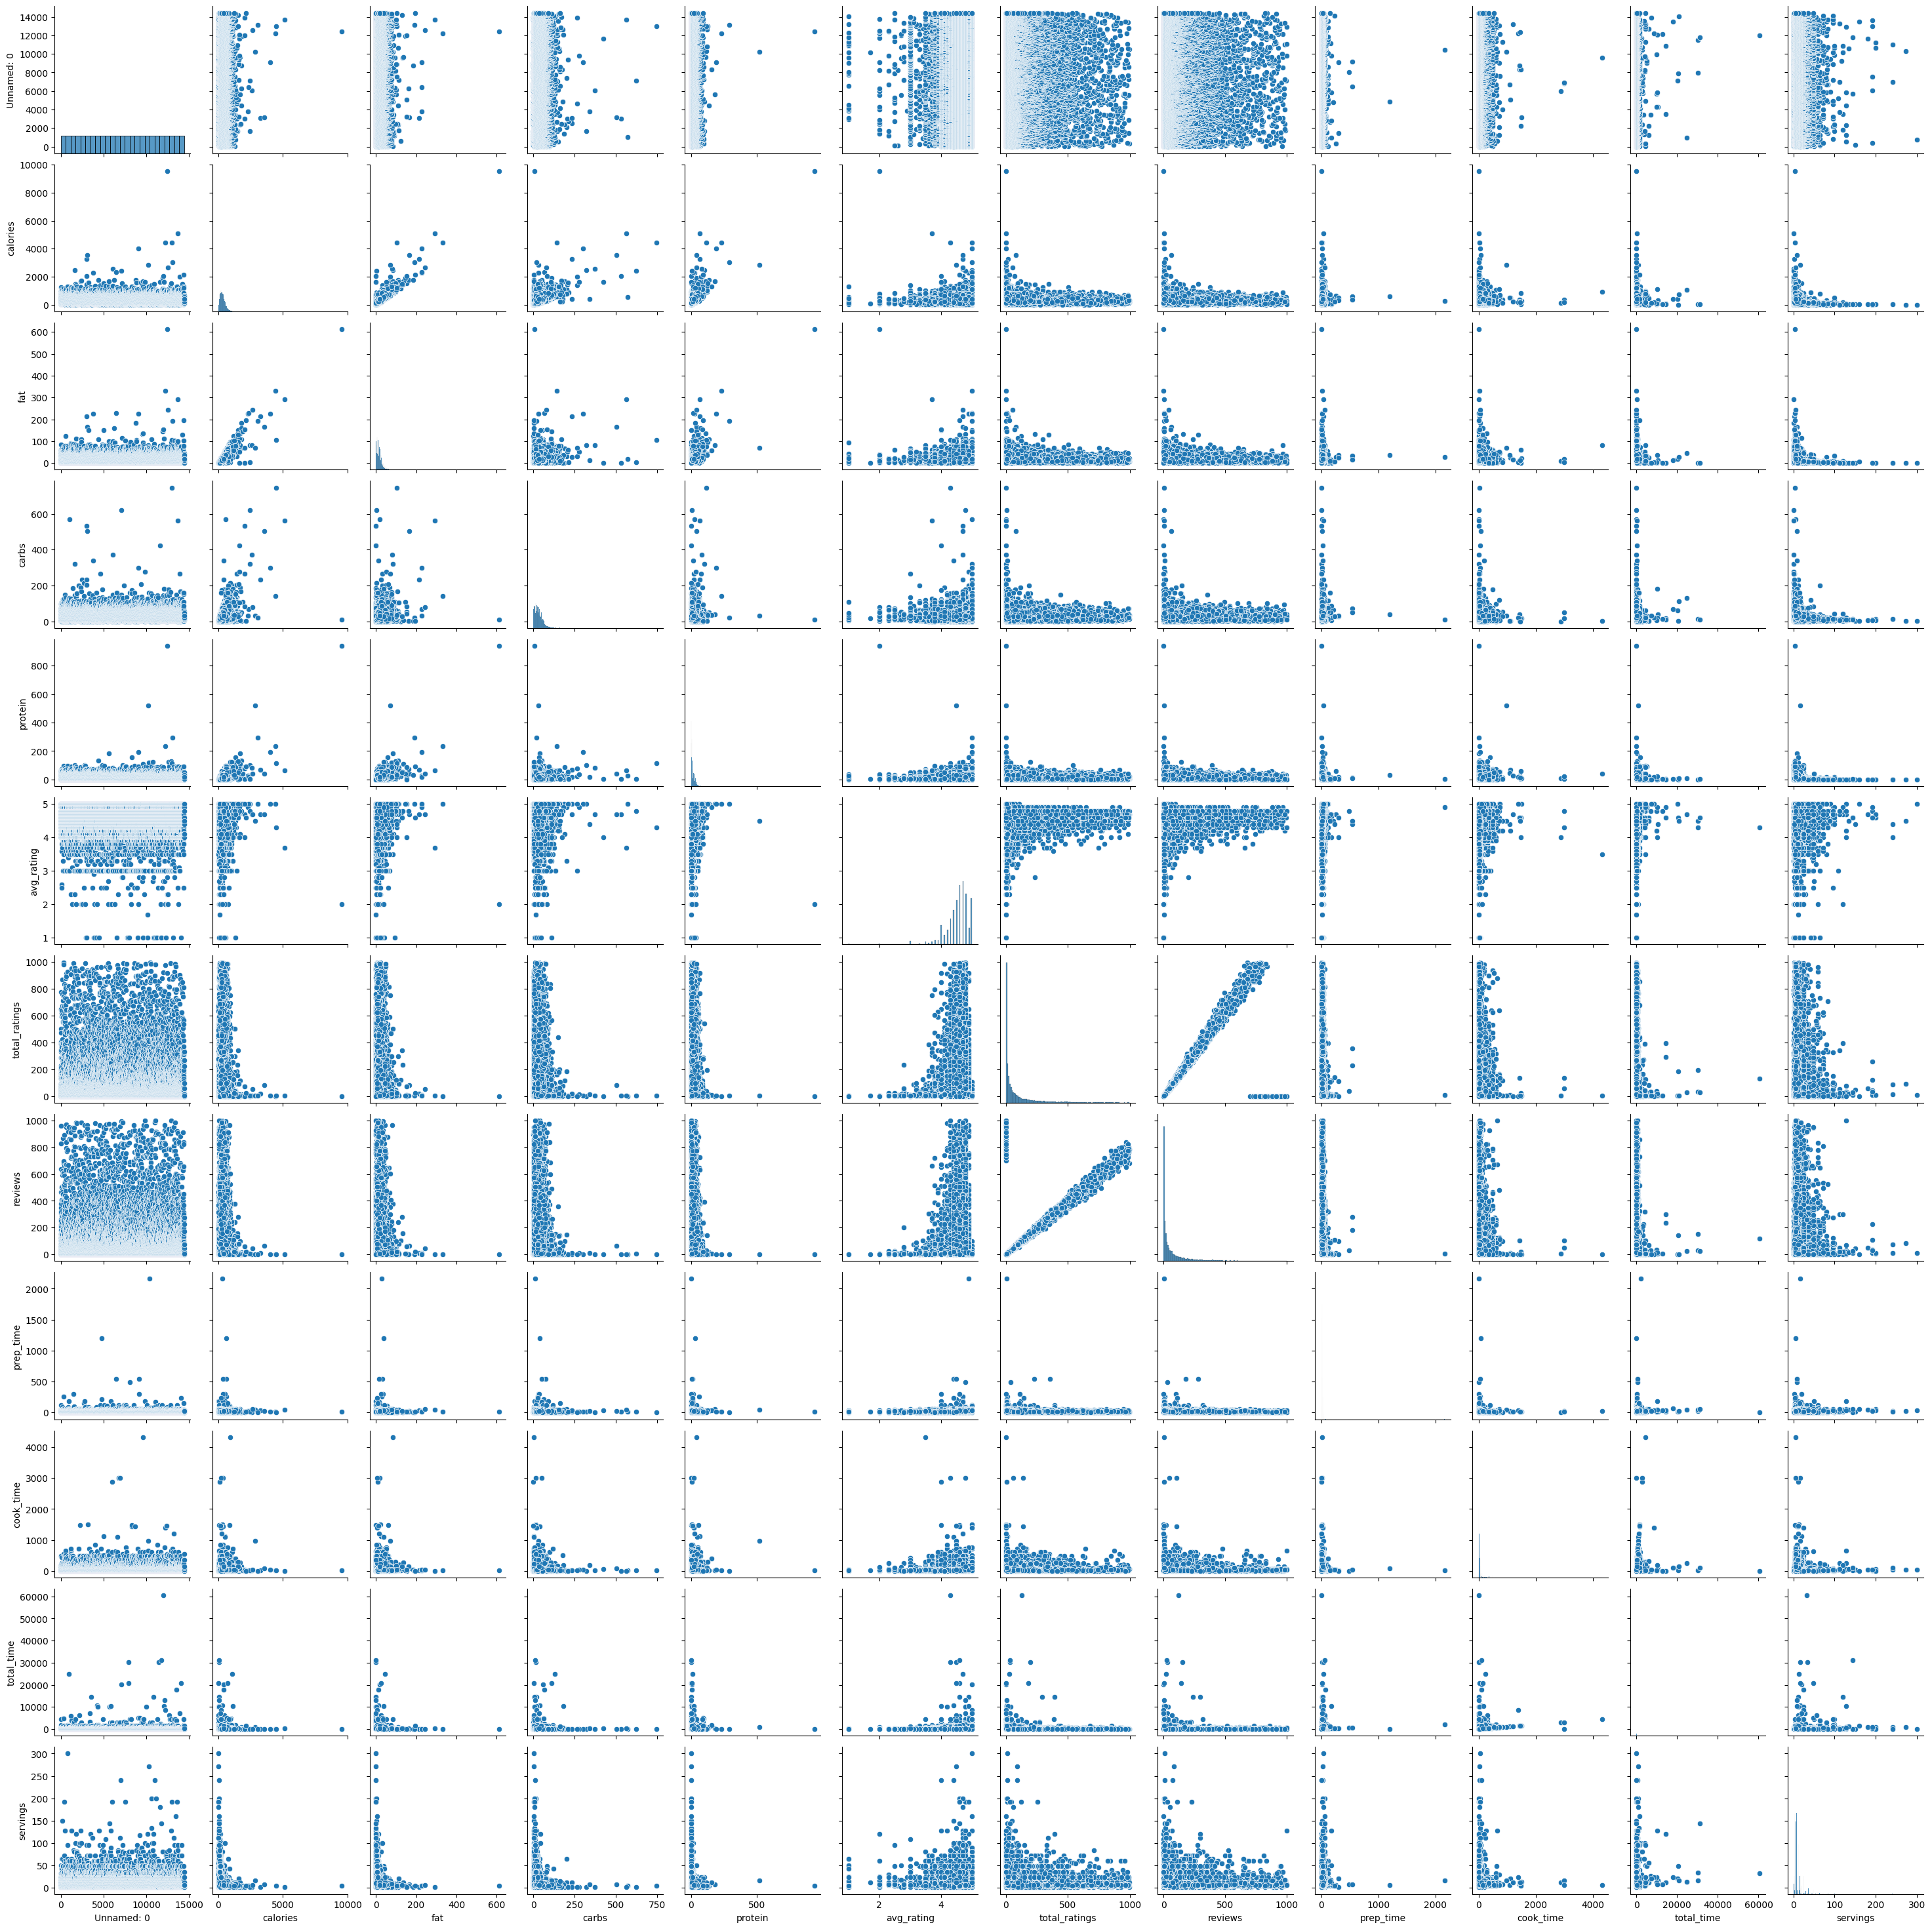

In [28]:
sns.pairplot(recetas)
plt.show()

In [38]:
sns.set_palette("magma")
sns.histplot(data=recetas, x = "reviews", hue="servings" )
plt.show()

KeyboardInterrupt: 

In [ ]:
sns.catplot(data=titanic, x="cat_calories" y="")

In [47]:
titanic = sns.load_dataset("titanic")

In [48]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [43]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [51]:
titanic['embark_town'] = titanic['embark_town'].astype('category')
titanic['alive'] = titanic['alive'].astype('category')
titanic['sex'] = titanic['sex'].astype('category')

In [52]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    category
 13  alive        891 non-null    category
 14  alone        891 non-null    bool    
dtypes: bool(2), category(5), float64(2), int64(4), object(2)
memory usage: 62.8+ KB


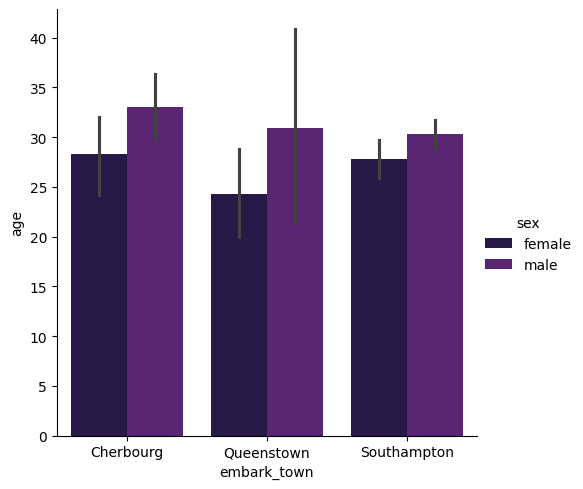

In [61]:
sns.catplot(data=titanic, x="embark_town", y="age", kind="bar" , hue = "sex")
plt.show()